In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds so results are more reproducible
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Define the class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Scale pixel values to the range [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert class labels to one-hot encoded format
y_train_full_cat = to_categorical(y_train_full, 10)
y_test_cat = to_categorical(y_test, 10)

# Split the training data into training and validation sets
x_train, x_val, y_train_cat, y_val_cat, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full_cat,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# Print dataset shapes
print("Training set shape:", x_train.shape)
print("Validation set shape:", x_val.shape)
print("Test set shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training set shape: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


/tmp/ipykernel_184/1921403777.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


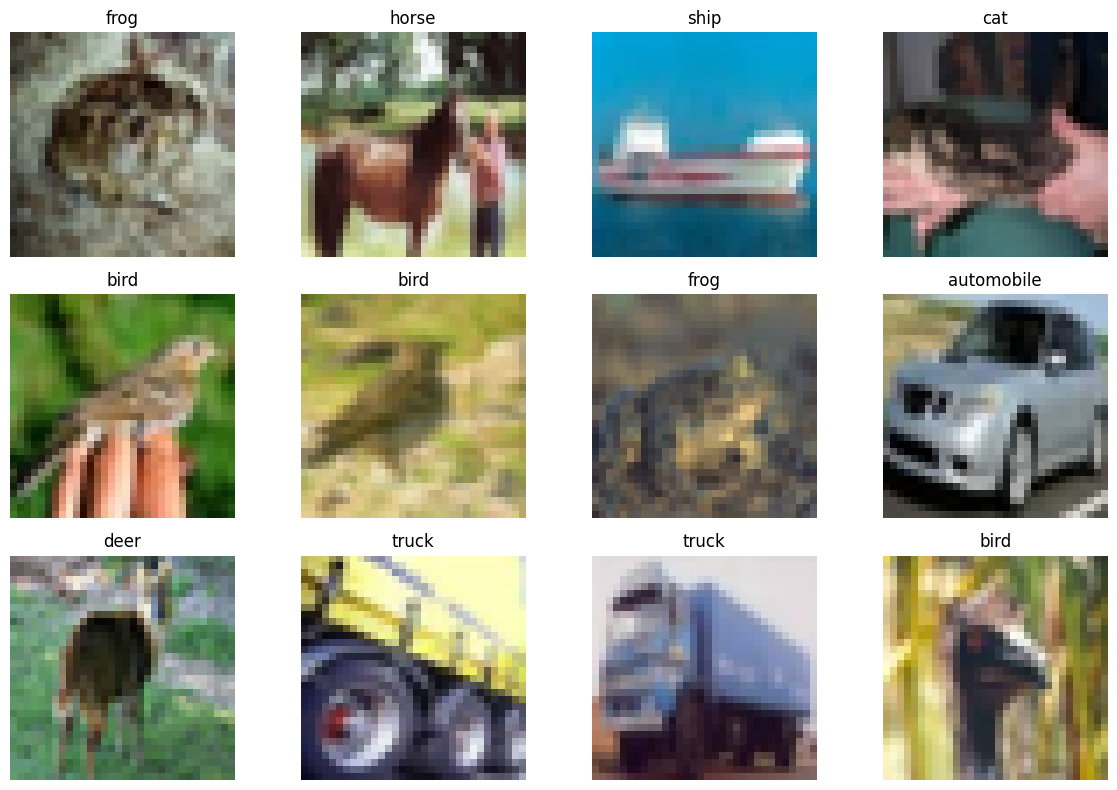

In [ ]:
# Show a few example images from the training set
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.savefig("figure_1_sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

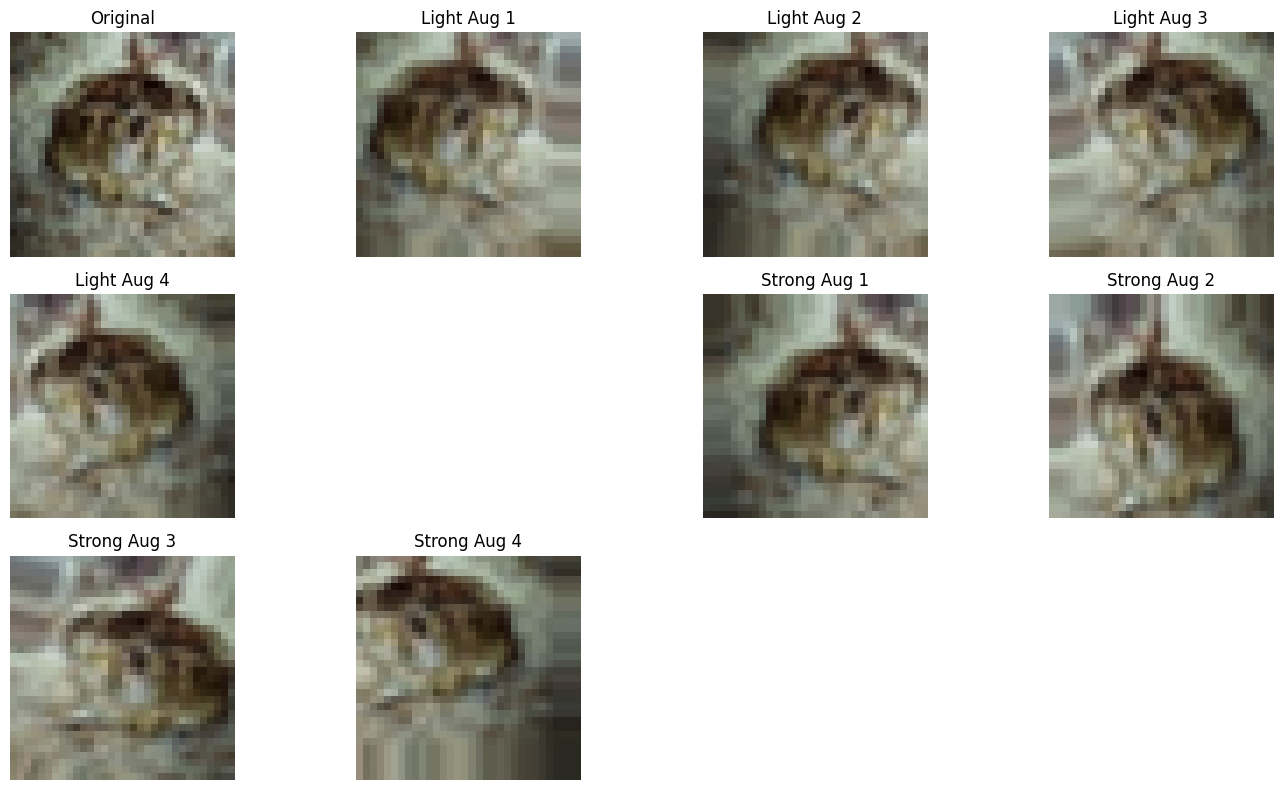

In [ ]:
# Create a light augmentation generator
light_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Create a stronger augmentation generator
strong_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

# Select one image to demonstrate augmentation
sample_image = x_train[0]
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Plot the original image and augmented versions
plt.figure(figsize=(14, 8))

plt.subplot(3, 4, 1)
plt.imshow(sample_image)
plt.title("Original")
plt.axis("off")

# Generate examples of light augmentation
light_iter = light_datagen.flow(sample_image_batch, batch_size=1)
for i in range(4):
    augmented_image = next(light_iter)[0]
    plt.subplot(3, 4, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Light Aug {i + 1}")
    plt.axis("off")

# Generate examples of strong augmentation
strong_iter = strong_datagen.flow(sample_image_batch, batch_size=1)
for i in range(4):
    augmented_image = next(strong_iter)[0]
    plt.subplot(3, 4, i + 7)
    plt.imshow(augmented_image)
    plt.title(f"Strong Aug {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("figure_2_augmentation_examples.png", dpi=300,
            bbox_inches="tight")
plt.show()

In [ ]:
# Build a CNN model that will be used for all three experiments
def build_cnn_model():
    model = Sequential([
        Conv2D(
            32, (3, 3), activation="relu",
            padding="same", input_shape=(32, 32, 3)
        ),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Set common training parameters
epochs = 15
batch_size = 64

In [ ]:
# Create a model instance and display its architecture
baseline_model = build_cnn_model()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Create a dictionary to store the training histories
histories = {}

# Train the baseline CNN without augmentation
baseline_model = build_cnn_model()
histories["Baseline"] = baseline_model.fit(
    x_train,
    y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val_cat),
    verbose=1
)

# Train the CNN with light augmentation
light_aug_model = build_cnn_model()
histories["Light Aug"] = light_aug_model.fit(
    light_datagen.flow(x_train, y_train_cat, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_val, y_val_cat),
    verbose=1
)

# Train the CNN with stronger augmentation
strong_aug_model = build_cnn_model()
histories["Strong Aug"] = strong_aug_model.fit(
    strong_datagen.flow(x_train, y_train_cat, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_val, y_val_cat),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 199ms/step - accuracy: 0.3832 - loss: 1.7041 - val_accuracy: 0.5275 - val_loss: 1.3096
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 193ms/step - accuracy: 0.5281 - loss: 1.3138 - val_accuracy: 0.5370 - val_loss: 1.3384
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 196ms/step - accuracy: 0.6103 - loss: 1.1042 - val_accuracy: 0.6625 - val_loss: 0.9588
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 192ms/step - accuracy: 0.6601 - loss: 0.9673 - val_accuracy: 0.6287 - val_loss: 1.0515
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 193ms/step - accuracy: 0.6975 - loss: 0.8688 - val_accuracy: 0.7153 - val_loss: 0.8252
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 193ms/step - accuracy: 0.7257 - loss: 0.7810 - val_accuracy: 0.6986 - val_loss: 0.9025
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 194ms/step - accuracy: 0.7477 - loss: 0.7219 - val_accuracy: 0.6684 - val_loss: 1.0798
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.7732 -

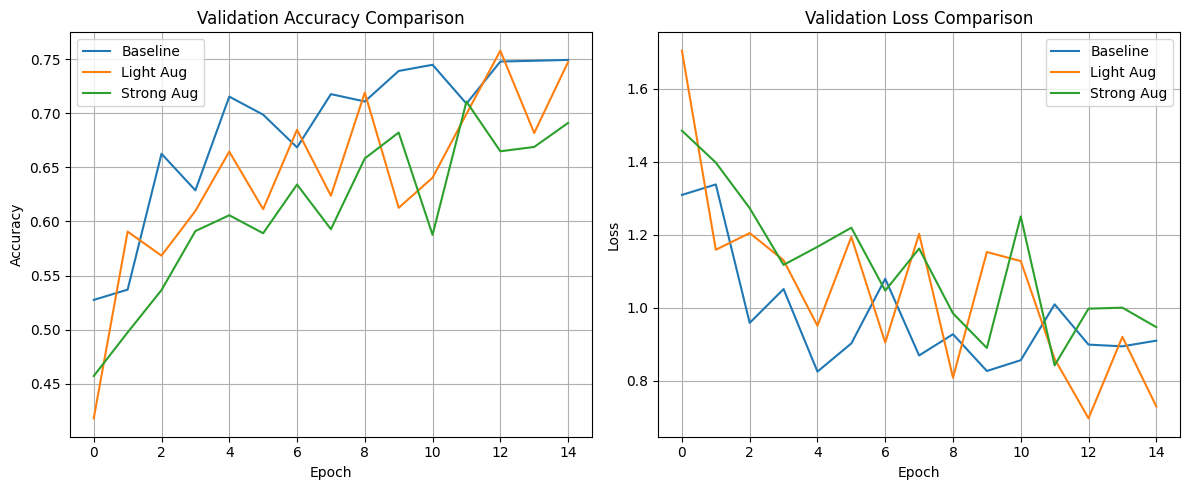

In [ ]:
# Plot validation accuracy and validation loss for all three models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(histories["Baseline"].history["val_accuracy"], label="Baseline")
plt.plot(histories["Light Aug"].history["val_accuracy"], label="Light Aug")
plt.plot(histories["Strong Aug"].history["val_accuracy"], label="Strong Aug")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(histories["Baseline"].history["val_loss"], label="Baseline")
plt.plot(histories["Light Aug"].history["val_loss"], label="Light Aug")
plt.plot(histories["Strong Aug"].history["val_loss"], label="Strong Aug")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figure_3_validation_comparison.png", dpi=300,
            bbox_inches="tight")
plt.show()

Baseline CNN Test Accuracy:        0.7516
Light Augmentation Test Accuracy:  0.7501
Strong Augmentation Test Accuracy: 0.6917


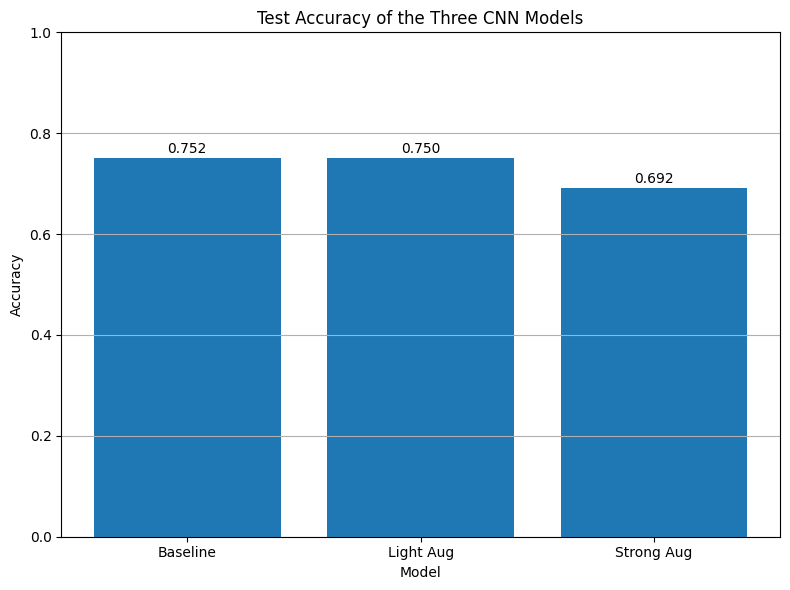

In [ ]:
# Evaluate all three models on the test set
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(
    x_test, y_test_cat, verbose=0
)
light_test_loss, light_test_acc = light_aug_model.evaluate(
    x_test, y_test_cat, verbose=0
)
strong_test_loss, strong_test_acc = strong_aug_model.evaluate(
    x_test, y_test_cat, verbose=0
)

# Print the final test accuracies
print("Baseline CNN Test Accuracy:       ", round(baseline_test_acc, 4))
print("Light Augmentation Test Accuracy: ", round(light_test_acc, 4))
print("Strong Augmentation Test Accuracy:", round(strong_test_acc, 4))

# Compare the test accuracies in a bar chart
model_names = ["Baseline", "Light Aug", "Strong Aug"]
test_accuracies = [baseline_test_acc, light_test_acc, strong_test_acc]

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, test_accuracies)

plt.title("Test Accuracy of the Three CNN Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, axis="y")

for bar, value in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig("figure_4_test_accuracy_bar_chart.png", dpi=300,
            bbox_inches="tight")
plt.show()

In [ ]:
# Store the test accuracies in a dictionary
accuracies = {
    "Baseline": baseline_test_acc,
    "Light Aug": light_test_acc,
    "Strong Aug": strong_test_acc
}

# Select the model with the highest test accuracy
best_model_name = max(accuracies, key=accuracies.get)
print("Best model:", best_model_name)

# Assign the best-performing model
if best_model_name == "Baseline":
    best_model = baseline_model
elif best_model_name == "Light Aug":
    best_model = light_aug_model
else:
    best_model = strong_aug_model

# Predict the class labels for the test set
y_pred_probs = best_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

Best model: Baseline
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


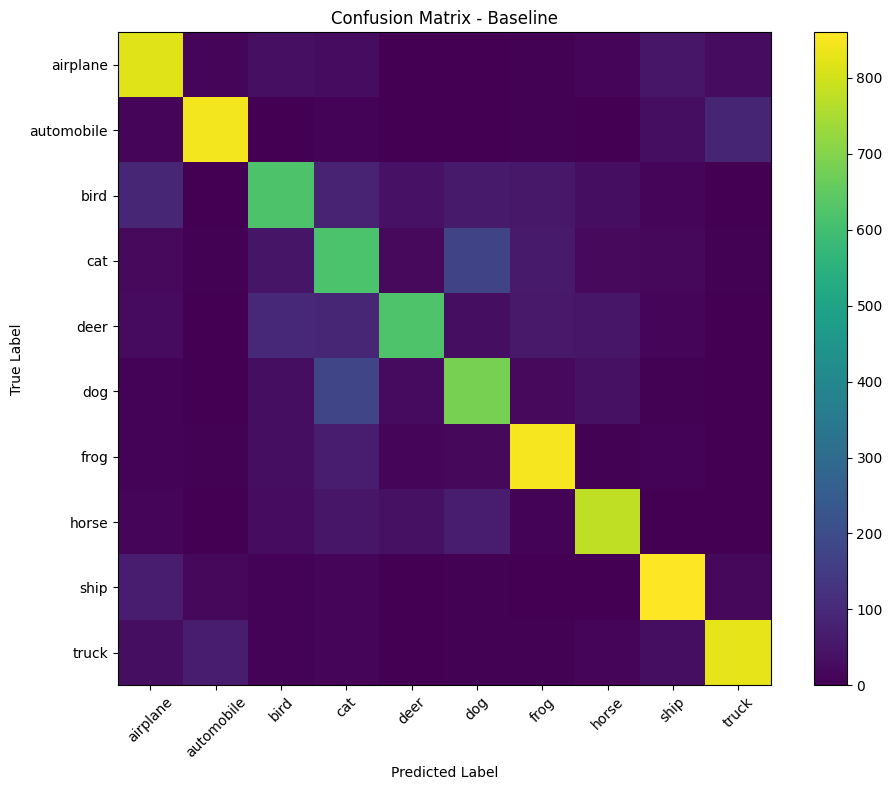

              precision    recall  f1-score   support

    airplane       0.74      0.82      0.78      1000
  automobile       0.88      0.84      0.86      1000
        bird       0.68      0.62      0.65      1000
         cat       0.54      0.61      0.57      1000
        deer       0.81      0.62      0.70      1000
         dog       0.64      0.68      0.66      1000
        frog       0.79      0.85      0.82      1000
       horse       0.82      0.78      0.80      1000
        ship       0.83      0.86      0.85      1000
       truck       0.85      0.83      0.84      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



In [ ]:
# Create a confusion matrix for the best model
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("figure_5_confusion_matrix.png", dpi=300,
            bbox_inches="tight")
plt.show()

# Print the classification report
print(classification_report(y_true, y_pred, target_names=class_names))

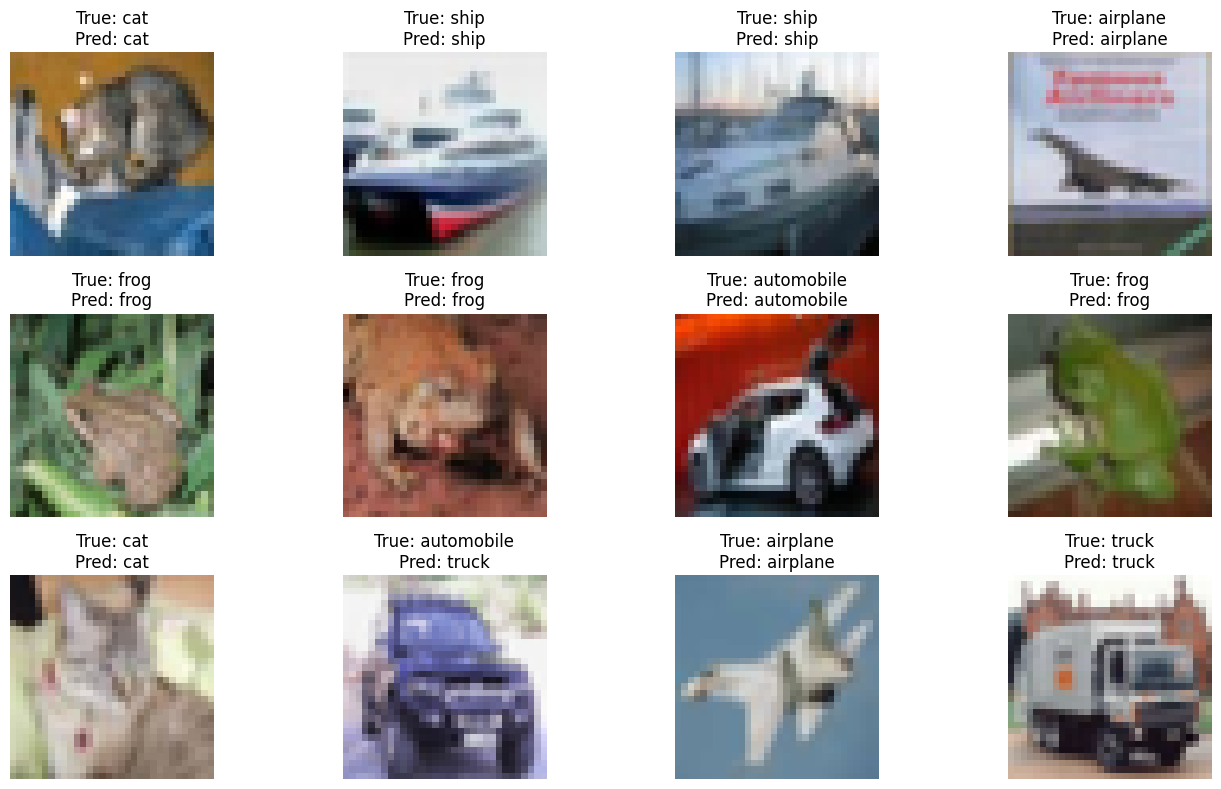

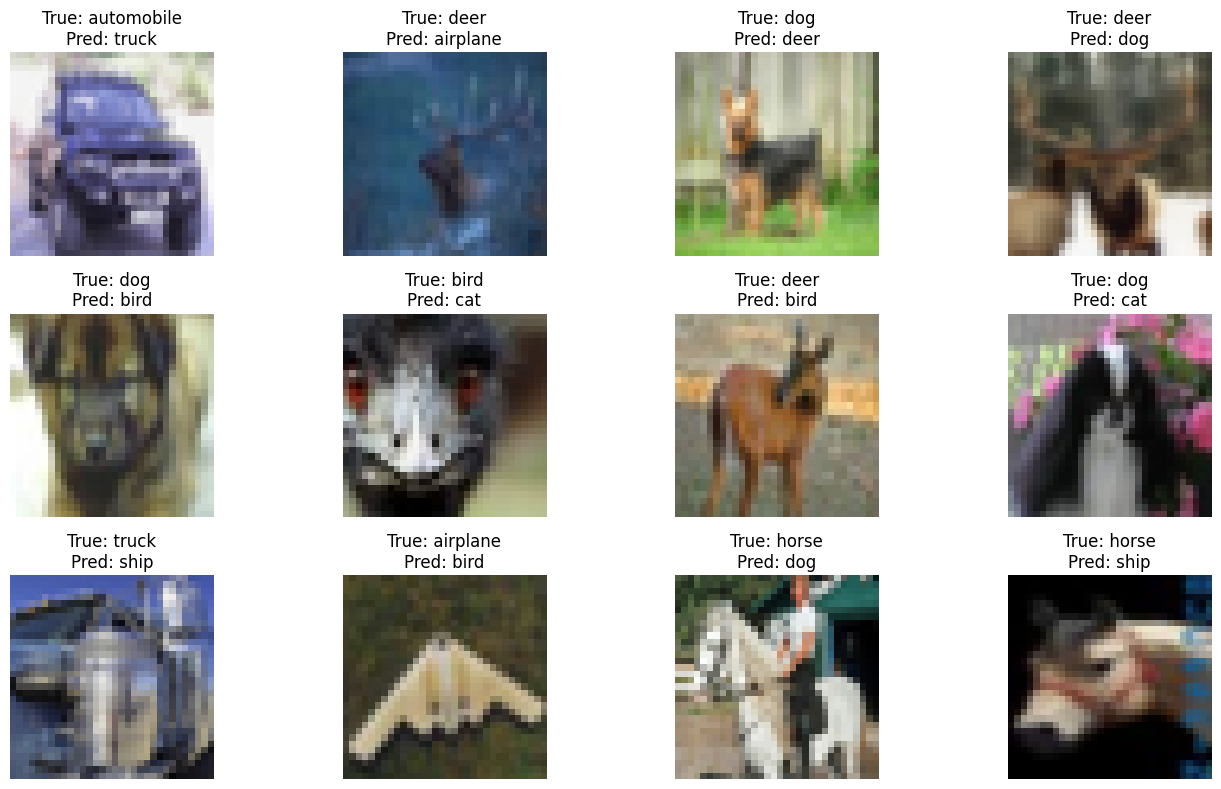

In [ ]:
# Display the first 12 predictions from the best model
plt.figure(figsize=(14, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("figure_6_prediction_examples.png", dpi=300,
            bbox_inches="tight")
plt.show()

# Display 12 incorrect predictions to show where the model struggles
incorrect_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(14, 8))

for i in range(12):
    idx = incorrect_indices[i]
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("figure_7_incorrect_predictions.png", dpi=300,
            bbox_inches="tight")
plt.show()